# 📊 Data Envelopment Analysis (DEA)

## 📦 1. Instalación de librerías *necesarias*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 📚 2. Carga de librerías y del dataset

In [2]:
# Cargar el dataset desde un archivo CSV (cambia la ruta al archivo si es necesario)
data = pd.read_csv('Salary_dataset.csv')

# Verificar las primeras filas
data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


## 🔍 3. Exploración inicial del dataset (head y tipos de datos)

In [3]:
# Ver las dimensiones del nuevo dataset
print(f"Dimensiones de dataset: {data.shape}")

# Ver la estructura del nuevo dataset
print(f"Estructura de data_cleaned:")
print(data.info())

Dimensiones de dataset: (30, 3)
Estructura de data_cleaned:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


## 🔔 4. KDE

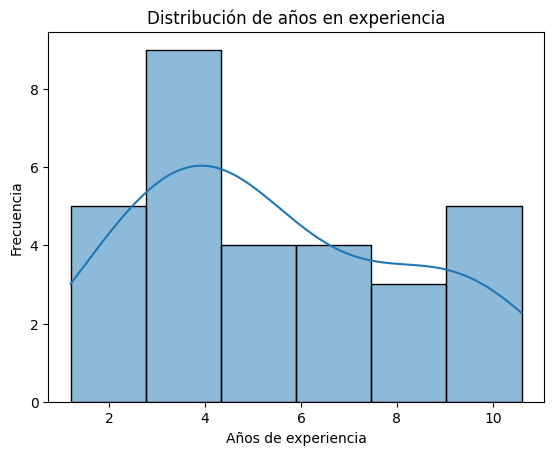

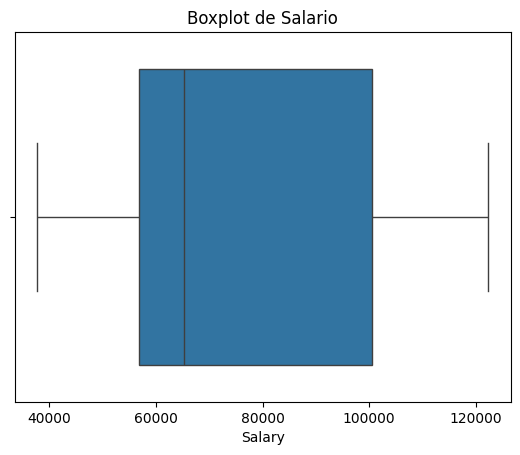

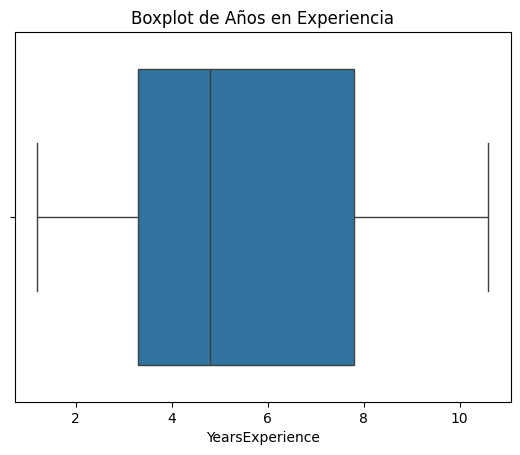

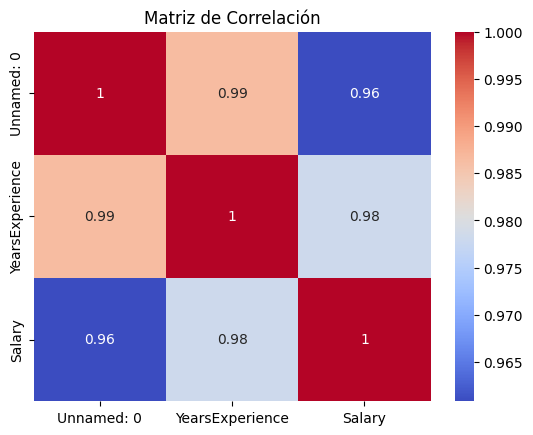

In [4]:
# Visualizar la distribución de una variable (glucosa en el ejemplo de R)
sns.histplot(data['YearsExperience'], kde=True)
plt.title("Distribución de años en experiencia")
plt.xlabel("Años de experiencia")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot para detectar valores atípicos
sns.boxplot(x=data['Salary'])
plt.title("Boxplot de Salario")
plt.show()

# Boxplot para detectar valores atípicos
sns.boxplot(x=data['YearsExperience'])
plt.title("Boxplot de Años en Experiencia")
plt.show()

# Identificación de correlaciones
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

# Análisis de Componentes Principales (PCA)

Proporción de varianza explicada por cada componente:  [0.98041297 0.01958703]


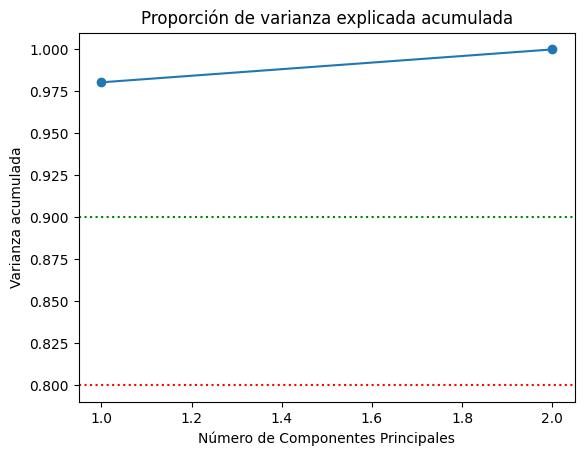

In [8]:

# Ahora aplicar PCA sobre los datos limpios
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalizar los datos antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop('YearsExperience', axis=1))

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Proporción de varianza explicada por cada componente
pve = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente: ", pve)

# Visualizar el gráfico de varianza acumulada
plt.plot(range(1, len(pve)+1), np.cumsum(pve), marker='o')
plt.axhline(y=0.80, color='red', linestyle=':', label='80% Varianza Explicada')
plt.axhline(y=0.90, color='green', linestyle=':', label='90% Varianza Explicada')
plt.title("Proporción de varianza explicada acumulada")
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza acumulada")
plt.show()

# Regresión Lineal

In [10]:
#Librerias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir variables: caracteristica (X) y la variable objetivo (y)
X = data[['YearsExperience']]
y = data['Salary']

# Division de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=58
)

In [11]:
# Entrenamiento del modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Predicciones en el conjunto de prueba
y_pred = lin_reg.predict(X_test)

In [14]:
import math
# Evaluación del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse=math.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.2f}")

MAE: 6772.28
MSE: 7143.08
R^2: 0.48


### Visualización

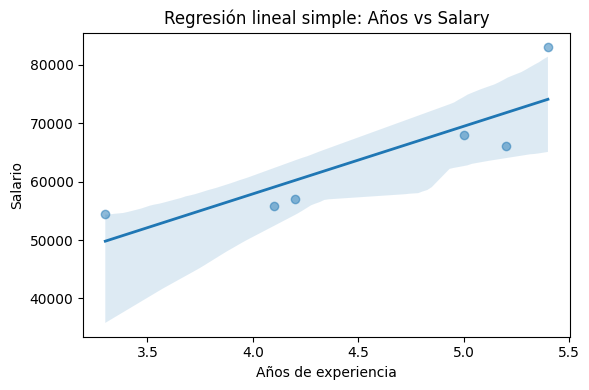

In [15]:
# Visualización de la regresión
plt.figure(figsize=(6,4))
sns.regplot(x=X_test['YearsExperience'], y=y_test, scatter_kws={'alpha':0.5}, line_kws={'linewidth':2})
plt.title('Regresión lineal simple: Años vs Salary')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.tight_layout()
plt.show()

c:\Users\guill\Escritorio\INFORMATICA\data-science\data-science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


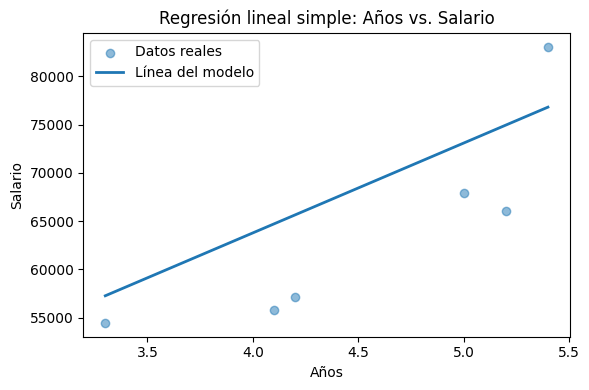

In [17]:
# 5) Visualizar (el modelo, no el ajuste interno de seaborn)
plt.figure(figsize=(6,4))
plt.scatter(X_test['YearsExperience'], y_test, alpha=0.5, label='Datos reales')
# Línea del modelo:
x_line = np.linspace(X_test['YearsExperience'].min(), X_test['YearsExperience'].max(), 100).reshape(-1,1)
y_line = lin_reg.predict(x_line)
plt.plot(x_line, y_line, linewidth=2, label='Línea del modelo')
plt.title('Regresión lineal simple: Años vs. Salario')
plt.xlabel('Años')
plt.ylabel('Salario')
plt.legend()
plt.tight_layout()
plt.show()